In [1]:
import numpy as np
import faiss

embeddings = np.load("data/unsplash/embeddings.npy")
ids = np.load("data/unsplash/ids.npy", allow_pickle=True)

In [2]:
d = embeddings.shape[1]

index = faiss.IndexHNSWFlat(d, 32)
index.hnsw.efConstruction = 200

index.add(embeddings)
index.hnsw.efSearch = 50

In [3]:
def search_by_index(i, k=5):
    query = embeddings[i].reshape(1, -1)
    distances, indices = index.search(query, k)

    print("Query ID:", ids[i])
    print("Results:", [ids[idx] for idx in indices[0]])
    print("Scores:", distances[0])

In [4]:
flat_index = faiss.read_index("data/unsplash/index.faiss")


In [5]:
hnsw_index = faiss.read_index("data/unsplash/index_hnsw.faiss")
hnsw_index.hnsw.efSearch = 50

In [6]:
def search(index, i, k=5):
    query = embeddings[i].reshape(1, -1)
    distances, indices = index.search(query, k)
    return indices[0], distances[0]

In [7]:
i = 100

hnsw_idx, hnsw_dist = search(hnsw_index, i)
flat_idx, flat_dist = search(flat_index, i)

print("HNSW:", hnsw_idx)
print("Flat:", flat_idx)

HNSW: [ 100 1959  514  829   65]
Flat: [ 100 3839 8452 5638 7526]


In [8]:
import random

def overlap(a, b):
    return len(set(a) & set(b)) / len(a)

scores = []

for _ in range(50):
    i = random.randint(0, len(ids)-1)

    hnsw_idx, _ = search(hnsw_index, i)
    flat_idx, _ = search(flat_index, i)

    scores.append(overlap(hnsw_idx, flat_idx))

print("Average overlap:", sum(scores)/len(scores))

Average overlap: 0.012000000000000002


In [9]:
import time

def benchmark(index, n=100):
    start = time.time()

    for _ in range(n):
        i = random.randint(0, len(ids)-1)
        search(index, i)

    return time.time() - start

print("Flat time:", benchmark(flat_index))
print("HNSW time:", benchmark(hnsw_index    ))

Flat time: 0.07354307174682617
HNSW time: 0.005502223968505859


In [10]:
def query_by_index(i, k=5):
    query_vec = embeddings[i].reshape(1, -1)
    distances, indices = index.search(query_vec, k)

    print("Query ID:", ids[i])
    print("Results:", [ids[idx] for idx in indices[0]])
    print("Scores:", distances[0])

In [11]:
query_by_index(100)

Query ID: SoC1ex6sI4w
Results: ['SoC1ex6sI4w', 'MXJ3QUxhNrY', 'm78EF2Rnp9A', '15mkCCDr9iY', 'Rj2Xuc6-cd0']
Scores: [0.         0.21450122 0.23066545 0.23346823 0.24601458]


In [12]:
import matplotlib.pyplot as plt

def show_results(i, k=3):
    plt.figure(figsize=(15, 3))

    # ---- query ----
    query_url = id_to_url[ids[i]]
    query_url = query_url + "&w=256" if "?" in query_url else query_url + "?w=256"
    query_img = fetch_image(query_url)

    plt.subplot(1, k+1, 1)
    if query_img:
        plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    # ---- search ----
    query = embeddings[i].reshape(1, -1)
    distances, indices = index.search(query, k)

    # ---- results ----
    for j, idx in enumerate(indices[0]):
        base_url = id_to_url[ids[idx]]
        url = base_url + "&w=256" if "?" in base_url else base_url + "?w=256"
        img = fetch_image(url)

        plt.subplot(1, k+1, j+2)
        if img:
            plt.imshow(img)
        plt.title(f"{1 - distances[0][j]:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    print(url)

In [13]:
import numpy as np
import faiss
import pandas as pd

# load embeddings + ids
embeddings = np.load("data/unsplash/embeddings.npy")
ids = np.load("data/unsplash/ids.npy", allow_pickle=True)

# load HNSW index
index = faiss.read_index("data/unsplash/index_hnsw.faiss")
index.hnsw.efSearch = 50

# load metadata
df = pd.read_csv(
    "data/unsplash_lite/photos.csv",
    sep="\t",
    on_bad_lines="skip"
)

df = df.dropna(subset=["photo_image_url"])
df = df[df["photo_image_url"].str.startswith("https")]
df = df.reset_index(drop=True)

In [14]:
from functools import lru_cache
import requests
from PIL import Image
from io import BytesIO
import pandas as pd

# fast id → url mapping
id_to_url = dict(zip(df["photo_id"], df["photo_image_url"]))

@lru_cache(maxsize=2000)
def fetch_image(url):
    try:
        res = requests.get(url, timeout=5)
        if res.status_code != 200:
            return None
        img = Image.open(BytesIO(res.content)).convert("RGB")
        img.thumbnail((256, 256))
        return img
    except:
        return None

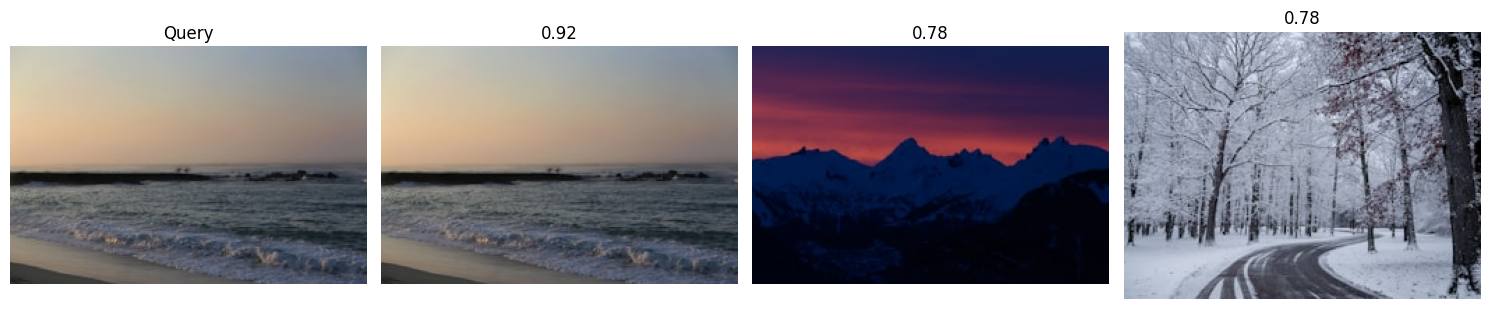

https://images.unsplash.com/photo-1550628339-45fe1bad3f5f?w=256


In [17]:
show_results(92)